In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('1nsurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
# reading the first colummns
head = df.head(10) 
head

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
# reading the last columns
tail = df.tail(10)
tail

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


In [14]:
# checking the data types
dtype=df.dtypes

In [15]:
dtype

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [17]:
# checking for the descriptive properties of the data
des = df.describe()

In [18]:
des

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [19]:
missing_data = df.isnull()

In [20]:
missing_data

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [25]:
# calculating for the outliers 
def find_outliers(bmi):
    Q1 = df[bmi].quantile(0.25)
    Q3 = df[bmi].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[bmi] < lower) | (df[bmi] > upper)]
    return lower, upper, outliers

# Calculate outliers for BMI and charges
bmi_lower, bmi_upper, bmi_outliers = find_outliers("bmi")
charges_lower, charges_upper, charges_outliers = find_outliers("charges")

print("BMI lower bound:", bmi_lower)
print("BMI upper bound:", bmi_upper)
print("Number of BMI outliers:", len(bmi_outliers))

print("Charges lower bound:", charges_lower)
print("Charges upper bound:", charges_upper)
print("Number of charges outliers:", len(charges_outliers))


BMI lower bound: 13.7
BMI upper bound: 47.290000000000006
Number of BMI outliers: 9
Charges lower bound: -13109.1508975
Charges upper bound: 34489.350562499996
Number of charges outliers: 139


In [23]:
# Calculating the univariate analysis
value_count= (df['smoker'].value_counts())


In [24]:
value_count

no     1064
yes     274
Name: smoker, dtype: int64

In [26]:
print(df['region'].value_counts())


southeast    364
southwest    325
northwest    325
northeast    324
Name: region, dtype: int64


<Axes: xlabel='bmi', ylabel='charges'>

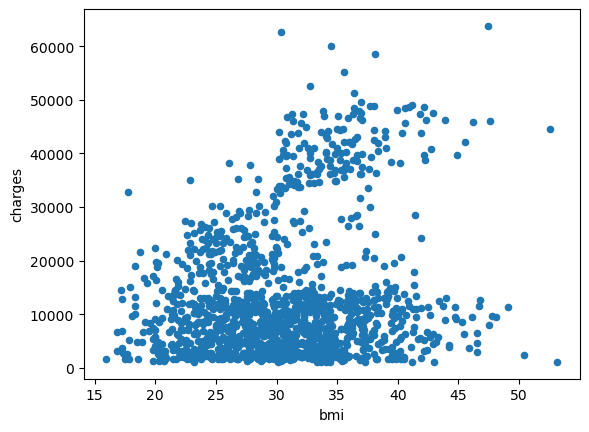

In [33]:
# plotting bmi vs charges
df.plot(kind='scatter', x='bmi', y='charges')

<Axes: title={'center': 'charges'}, xlabel='smoker'>

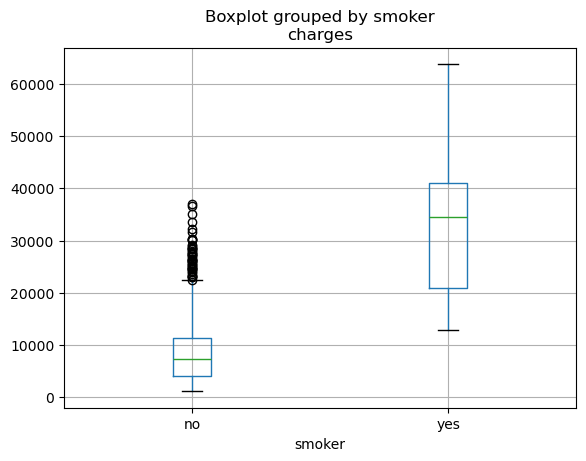

In [34]:
df.boxplot(column='charges', by='smoker')
# plotting charges vs smoker, so that i can know the insurance cost

In [35]:
pd.crosstab(df['sex'], df['smoker'])

smoker,no,yes
sex,,
female,547,115
male,517,159


In [36]:
df.corr()

C:\Users\eteag\AppData\Local\Temp\ipykernel_1192\1134722465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


From the above plots and correlation we can tell that
- Smoker status is the strongest predictor of charges
- BMI and age also matter
- Region has little effect
Smoker status consistently emerges as the strongest predictor of medical insurance charges, with BMI and age contributing meaningful but smaller effects and region showing very limited influence. These three insights sit at the core of how risk and cost behave in the insurance dataset you’ve been analysing, and they reflect broader real‑world health‑economics patterns.

Smoker status as the dominant predictor
Smoking creates a sharp divide in medical costs because it is linked to higher rates of chronic illness, hospitzlisation, and long‑term complications. In the dataset, smokers cluster at the very top of the cost distribution, often with charges several times higher than non‑smok'ers. This separation is so strong that smoking alone can explain a large portion of the variation in charges, and models that include it typically show it as the most influential feature. The effect is amplified when combined with high BMI or older age, creating a compounding risk profile.

BMI and age as secondary but meaningful factors
BMI and age both show clear relationships with charges, but neither produces the dramatic jump seen with smoking. Higher BMI is associated with increased risk of metabolic and cardiovascular conditions, which raises expected medical spending. Age contributes a steady upward trend because health risks accumulate over time, leading to more frequent or more complex care. These variables matter because they shape baseline risk, but their influence is gradual rather than abrupt.

Region with minimal effect on charges
Regional differences in the dataset are small and inconsistent, suggesting that location does not meaningfully alter individual medical costs. While real‑world healthcare systems sometimes show regional variation due to pricing, access, or policy differences, the dataset treats region more as a demographic label than a cost driver. As a result, it contributes little predictive power and often becomes optionalin m
delling.

These three patterns together explain why predictive models for insurance charges rely heavily on smoking status, refine accuracy with BMI and age, and treat region as a minor contextual variable



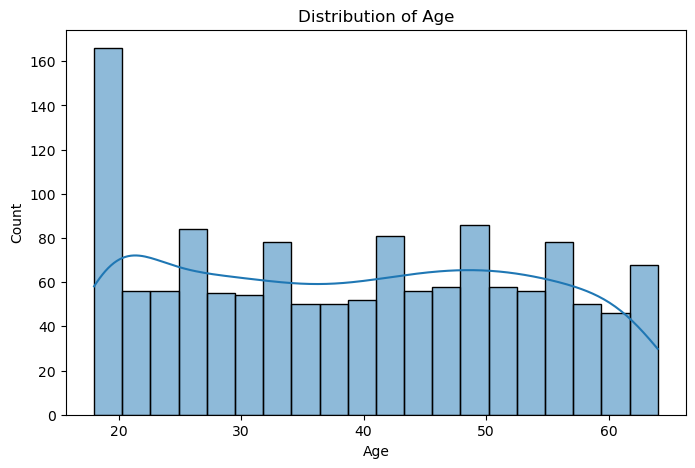

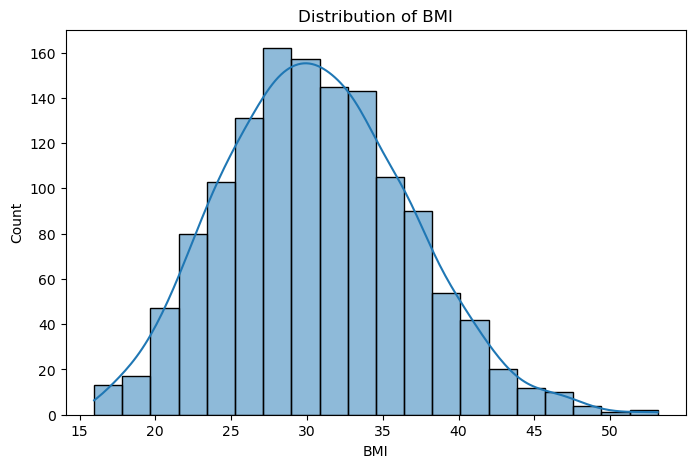

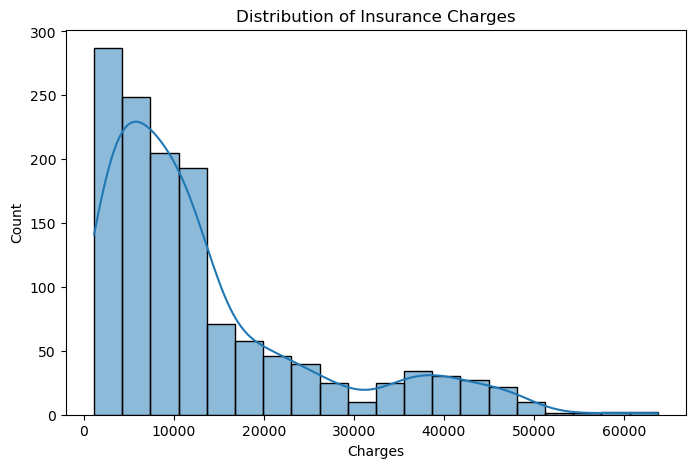

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for Age
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Histogram for BMI
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

# Histogram for Charges
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=20, kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

From the histogram plot:
- Age is fairly evenly spread.
- BMI has a long tail on the high end.
- Charges are strongly right‑skewed because a few people have extremely high medical costs.


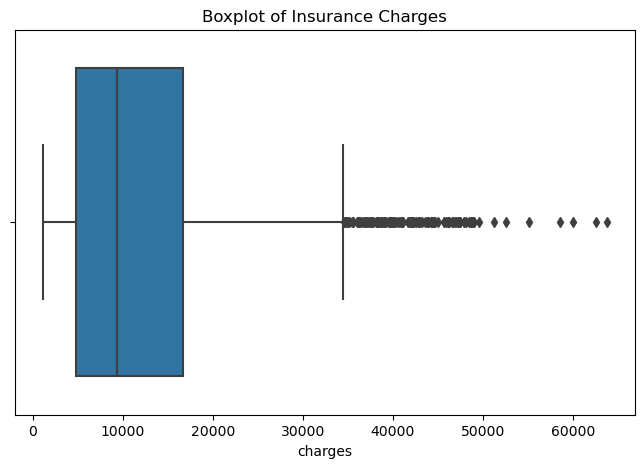

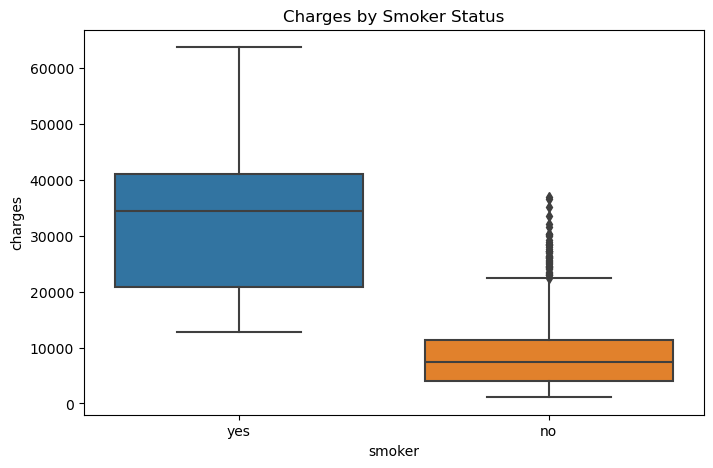

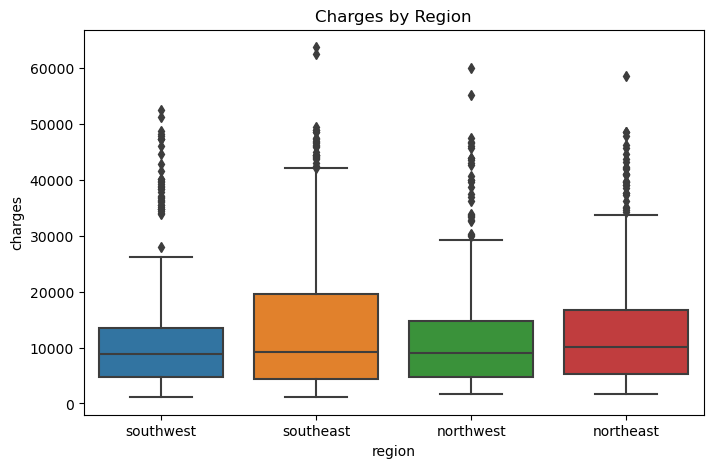

In [38]:
# Boxplot for Charges
plt.figure(figsize=(8,5))
sns.boxplot(x=df['charges'])
plt.title("Boxplot of Insurance Charges")
plt.show()

# Boxplot: Charges by Smoker Status
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoker Status")
plt.show()

# Boxplot: Charges by Region
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title("Charges by Region")
plt.show()

From the boxplot:
- Smokers have dramatically higher charges.
- Charges contain many high outliers.
- Regions show small differences


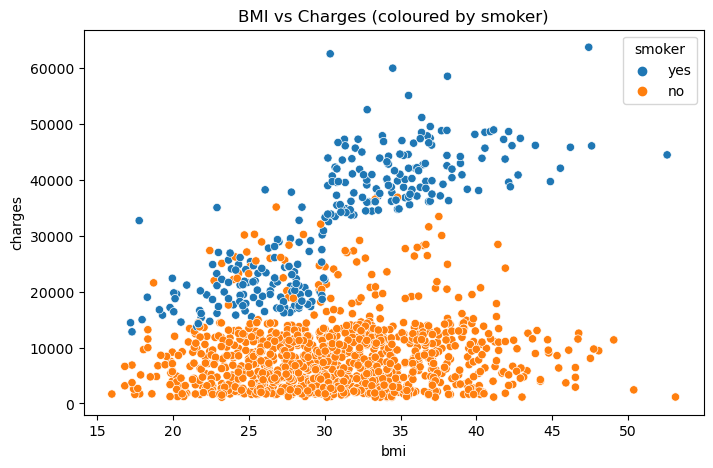

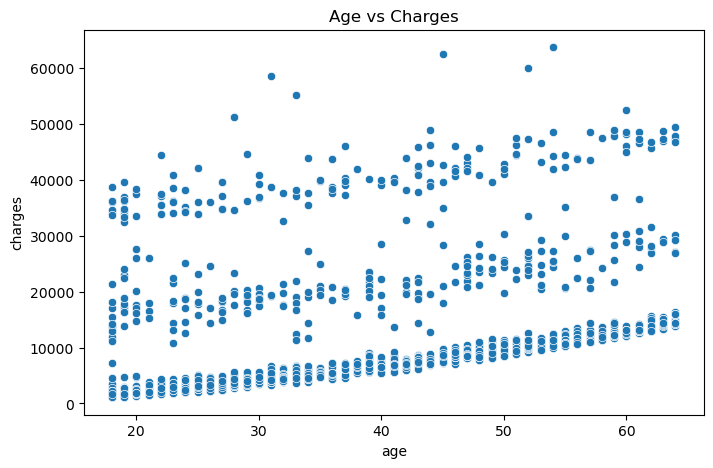

In [41]:
# Scatterplot: BMI vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker')
plt.title("BMI vs Charges (coloured by smoker)")
plt.show()

# Scatterplot: Age vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()


From the scatter diagram:
- BMI alone has a weak relationship with charges, but high‑BMI smokers show a steep rise.
- Charges increase with age, especially after age 40.


C:\Users\eteag\AppData\Local\Temp\ipykernel_1192\4092002889.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


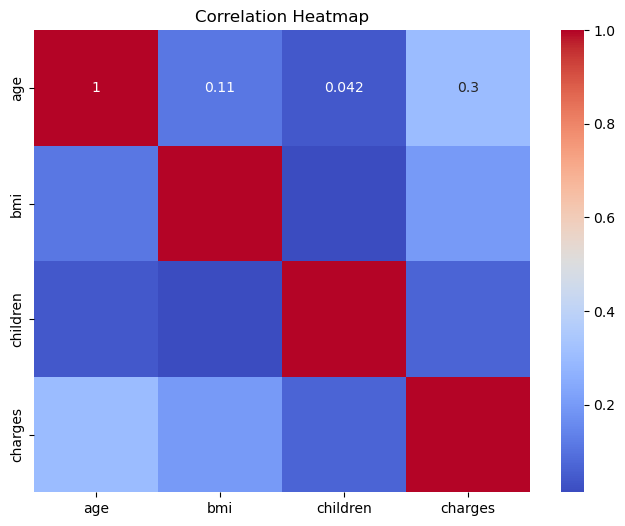

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

From the heatmap plot
- Charges correlate strongly with smoker status (after encoding).
- Age has a moderate positive correlation with charges.
- BMI has a weak correlation unless combined with smoking.
- Children, region, and sex show very weak correlations.


In [27]:
names = ["Mohamed", "Sara", "Xia", "Paul", "Valentina", "Jide", "Aaron", "Emily", "Nikita", "Paul"]
insurance_costs = [13262.0, 4816.0, 6839.0, 5054.0, 14724.0, 5360.0, 7640.0, 6072.0, 2750.0, 12064.0]

In [28]:
names.append('priscilla')

In [32]:
print(names)

['Mohamed', 'Sara', 'Xia', 'Paul', 'Valentina', 'Jide', 'Aaron', 'Emily', 'Nikita', 'Paul', 'priscilla']


In [31]:
insurance_costs.append(8320.0)
print(insurance_costs)

[13262.0, 4816.0, 6839.0, 5054.0, 14724.0, 5360.0, 7640.0, 6072.0, 2750.0, 12064.0, 8320.0, 8320.0]
